In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as  plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
le=LabelEncoder()
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import OneClassSVM
from itertools import product


In [2]:
trainDf=pd.read_csv('train_60_custom_script.csv')
testDf=pd.read_csv('test_60_custom_script.csv')

class_range=12 
le.fit(trainDf['Label'])
#drop the Labels from X_train/test and just keep the label on y_train/test
X_train=trainDf.drop('Label',axis=1)
y_train=le.transform(trainDf['Label'])
X_test=testDf.drop('Label',axis=1)
y_test=le.transform(testDf['Label'])

In [3]:
best=0
normal_train_Df=trainDf[trainDf['Label'].isin(['NORMAL'])]
y_test_real=testDf['Label'].apply(lambda label:1 if label=='NORMAL' else -1)
X_train_normal=normal_train_Df.drop('Label',axis=1)
for n_estimators,contamination in product([100,200,300],[0.01,0.02,0.033,0.05,0.1,0.2]):
    ilf=IsolationForest(
        n_estimators = n_estimators,
        contamination=contamination,
        random_state=63
    )
    ilf.fit(X_train_normal)
    pred=ilf.predict(X_test)
    print(f' Accuracy Score: {accuracy_score(y_test_real,pred)}')
    print(f'Classification Report \n{classification_report(y_test_real, pred, target_names=['Attack', 'Normal'])}')
    print(f'contamination :{contamination},\n n_estimators :{n_estimators}\n')
    if accuracy_score(y_test_real,pred)>best:
        best=accuracy_score(y_test_real,pred)
print(best)

 Accuracy Score: 0.9956349206349207
Classification Report 
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      2310
      Normal       0.96      0.99      0.97       210

    accuracy                           1.00      2520
   macro avg       0.98      0.99      0.99      2520
weighted avg       1.00      1.00      1.00      2520

contamination :0.01,
 n_estimators :100

 Accuracy Score: 0.998015873015873
Classification Report 
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      2310
      Normal       1.00      0.98      0.99       210

    accuracy                           1.00      2520
   macro avg       1.00      0.99      0.99      2520
weighted avg       1.00      1.00      1.00      2520

contamination :0.02,
 n_estimators :100

 Accuracy Score: 0.998015873015873
Classification Report 
              precision    recall  f1-score   support

      Attack       1.00      1.00 

In [4]:
best=0
scale=StandardScaler()
X_train_normal_scaled=scale.fit_transform(X_train_normal)
X_test_scaled=scale.transform(X_test)
for nu,gamma in product([0.01,0.03,0.05,0.1],[0.001,0.01,0.1]):
    svm=OneClassSVM(
        nu=nu,
        gamma=gamma,
        
        )
    svm.fit(X_train_normal_scaled)
    pred_svm=svm.predict(X_test_scaled)
    print(f'Accuracy Score: {accuracy_score(y_test_real,pred_svm)}')
    print(f'Classification Report \n {classification_report(y_test_real,pred_svm,target_names=['Attack','Normal'])}')
    print(f'nu :{nu} \n gamma : {gamma} \n')
    if best<accuracy_score(y_test_real,pred_svm):
        best=accuracy_score(y_test_real,pred_svm)
print(best)

Accuracy Score: 0.998015873015873
Classification Report 
               precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      2310
      Normal       1.00      0.98      0.99       210

    accuracy                           1.00      2520
   macro avg       1.00      0.99      0.99      2520
weighted avg       1.00      1.00      1.00      2520

nu :0.01 
 gamma : 0.001 

Accuracy Score: 0.9936507936507937
Classification Report 
               precision    recall  f1-score   support

      Attack       0.99      1.00      1.00      2310
      Normal       1.00      0.92      0.96       210

    accuracy                           0.99      2520
   macro avg       1.00      0.96      0.98      2520
weighted avg       0.99      0.99      0.99      2520

nu :0.01 
 gamma : 0.01 

Accuracy Score: 0.9412698412698413
Classification Report 
               precision    recall  f1-score   support

      Attack       0.94      1.00      0.97      2310
      No

In [17]:
import torch 
import torch.nn as nn
n_features = X_train_normal.shape[1]
loss_history = []
encoder = nn.Sequential(
    nn.Linear(n_features,n_features//2),
    nn.Sigmoid(),
    nn.Linear(n_features//2,n_features//4),
    nn.Sigmoid()
)
decoder =nn.Sequential(
    nn.Linear(n_features//4,n_features//2),
    nn.Sigmoid(),
    nn.Linear(n_features//2,n_features)
)
X_train_normal_tensor=torch.FloatTensor(X_train_normal_scaled)

autoencoder=nn.Sequential(encoder,decoder)
loss_function=nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
epochs=1000

for epoch in range(epochs):
    outputs=(autoencoder(X_train_normal_tensor))
    losses=(loss_function(outputs,X_train_normal_tensor))
    optimizer.zero_grad()
    losses.backward()
    optimizer.step()
    loss_history.append(losses.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {losses.item():.4f}")              


Epoch 0, Loss: 0.8177
Epoch 10, Loss: 0.7407
Epoch 20, Loss: 0.7303
Epoch 30, Loss: 0.7282
Epoch 40, Loss: 0.7241
Epoch 50, Loss: 0.7168
Epoch 60, Loss: 0.7022
Epoch 70, Loss: 0.6748
Epoch 80, Loss: 0.6338
Epoch 90, Loss: 0.5887
Epoch 100, Loss: 0.5500
Epoch 110, Loss: 0.5146
Epoch 120, Loss: 0.4761
Epoch 130, Loss: 0.4346
Epoch 140, Loss: 0.3969
Epoch 150, Loss: 0.3701
Epoch 160, Loss: 0.3542
Epoch 170, Loss: 0.3448
Epoch 180, Loss: 0.3386
Epoch 190, Loss: 0.3345
Epoch 200, Loss: 0.3318
Epoch 210, Loss: 0.3299
Epoch 220, Loss: 0.3285
Epoch 230, Loss: 0.3274
Epoch 240, Loss: 0.3265
Epoch 250, Loss: 0.3258
Epoch 260, Loss: 0.3251
Epoch 270, Loss: 0.3244
Epoch 280, Loss: 0.3238
Epoch 290, Loss: 0.3231
Epoch 300, Loss: 0.3224
Epoch 310, Loss: 0.3215
Epoch 320, Loss: 0.3205
Epoch 330, Loss: 0.3193
Epoch 340, Loss: 0.3178
Epoch 350, Loss: 0.3157
Epoch 360, Loss: 0.3130
Epoch 370, Loss: 0.3092
Epoch 380, Loss: 0.3040
Epoch 390, Loss: 0.2973
Epoch 400, Loss: 0.2898
Epoch 410, Loss: 0.2826
Epo

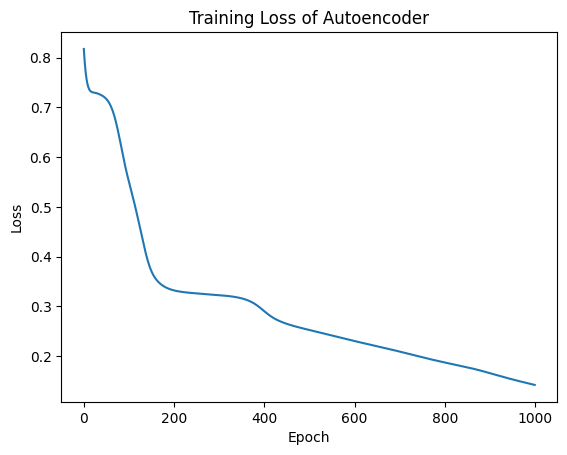

In [27]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss of Autoencoder')
plt.show()

As the number of epochs progresses the reconstruction loss of the normal samples reduces 

In [26]:
X_test_tensor=torch.FloatTensor(X_test_scaled)
with torch.no_grad():
    train_errors = torch.mean((X_train_normal_tensor - autoencoder(X_train_normal_tensor))**2, dim=1).numpy()
    test_errors = torch.mean((X_test_tensor - autoencoder(X_test_tensor))**2, dim=1).numpy()

threshold = np.percentile(train_errors, 99)     
pred_ae = np.where(test_errors > threshold, -1, 1)
print(classification_report(y_test_real, pred_ae, target_names=['Attack','Normal']))
print(accuracy_score(y_test_real,pred_ae))

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      2310
      Normal       1.00      0.98      0.99       210

    accuracy                           1.00      2520
   macro avg       1.00      0.99      0.99      2520
weighted avg       1.00      1.00      1.00      2520

0.9984126984126984


The best accuracy score goes to the Autoencoder with 0.9988, and second place is shared by the other two models with the same score of 0.9980. The Deep Learning model is better by 0.0008, which is 2 samples out of 2520.

# Best results — Anomaly Detection

| Model | Accuracy | Attack recall | Normal recall | Parameters |
|---|---|---|---|---|
| **Autoencoder** | **0.9988** | 1.00 | 0.99 | 1000 epochs, 99th-percentile threshold |
| Isolation Forest | 0.9980 | 1.00 | 0.98 | contamination 0.02, n_estimators 100 |
| One-Class SVM | 0.9980 | 1.00 | 0.98 | nu 0.01, gamma 0.001 |

---

### Isolation Forest — accuracy 0.9980

| class | precision | recall | f1 | support |
|---|---|---|---|---|
| Attack | 1.00 | 1.00 | 1.00 | 2310 |
| Normal | 1.00 | 0.98 | 0.99 | 210 |
| **macro avg** | 1.00 | 0.99 | 0.99 | 2520 |
| **weighted avg** | 1.00 | 1.00 | 1.00 | 2520 |

### One-Class SVM — accuracy 0.9980

| class | precision | recall | f1 | support |
|---|---|---|---|---|
| Attack | 1.00 | 1.00 | 1.00 | 2310 |
| Normal | 1.00 | 0.98 | 0.99 | 210 |
| **macro avg** | 1.00 | 0.99 | 0.99 | 2520 |
| **weighted avg** | 1.00 | 1.00 | 1.00 | 2520 |

### Autoencoder — accuracy 0.9988

| class | precision | recall | f1 | support |
|---|---|---|---|---|
| Attack | 1.00 | 1.00 | 1.00 | 2310 |
| Normal | 1.00 | 0.99 | 0.99 | 210 |
| **macro avg** | 1.00 | 0.99 | 0.99 | 2520 |
| **weighted avg** | 1.00 | 1.00 | 1.00 | 2520 |

---

All three models reach perfect recall on the Attack class, so no attack goes undetected. The difference is only on the Normal class: the Autoencoder misclassifies 3 normal flows out of 2520, the other two misclassify 5.